Valerie Jimenez and Trevor (mon and wed)
Multi-class Classification
https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025?select=cell_type_reference.csv

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df=pd.read_csv('blood_cell.csv')
df

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,CELL_003773,Platelet,0,Normal_Platelet,2.30,0.0,0.000,1.000,0.699,0.536,...,81.4,34.2,CytoData,May_Grunwald_Giemsa,Olympus_BX51,40,360,0.1178,1.0000,0.8849
5876,CELL_005192,Target_Cell,1,Anemia,8.80,0.0,0.000,1.000,0.831,0.199,...,88.1,34.4,Raabin_WBC,Giemsa,Zeiss_Axio,40,224,0.9034,0.9475,0.5928
5877,CELL_005227,Target_Cell,1,Anemia,9.57,0.0,0.000,1.000,0.900,0.320,...,86.7,34.0,PBC_Dataset,Giemsa,Olympus_BX51,40,256,0.8493,0.6716,0.6381
5878,CELL_005391,Hypersegmented_Neutrophil,1,Infection,11.98,67.8,0.528,0.309,0.752,0.505,...,96.5,32.9,CytoData,Giemsa,Leica_DM2000,100,256,0.9004,0.6449,0.8801


In [3]:
df.columns

Index(['cell_id', 'cell_type', 'anomaly_label', 'disease_category',
       'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density',
       'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score',
       'lobularity_score', 'membrane_smoothness', 'cell_area_px',
       'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity',
       'patient_age_group', 'patient_sex', 'wbc_count_per_ul',
       'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct',
       'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl', 'dataset_source',
       'staining_protocol', 'microscope_model', 'magnification_x',
       'image_resolution_px', 'cytodiffusion_anomaly_score',
       'cytodiffusion_classification_confidence', 'labeller_confidence_score'],
      dtype='object')

In [4]:
df.drop(columns=['cell_id', 'anomaly_label', 'patient_age_group', 'patient_sex',
                 'dataset_source', 'staining_protocol', 'microscope_model', 'magnification_x', 'image_resolution_px'])


,cell_type,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,...,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,Hypersegmented_Neutrophil,Infection,15.18,58.8,0.542,0.301,0.563,0.529,4.11,6.6,...,6352,4.44,11.7,43.4,257383,85.5,31.4,0.7649,0.5726,0.5670
1,Hypersegmented_Neutrophil,Infection,16.47,73.6,0.583,0.365,0.859,0.443,2.50,6.3,...,7709,4.90,13.9,42.2,302274,92.5,35.0,0.8472,0.7150,0.7273
2,Neutrophil,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,3.01,3.2,...,7451,5.72,16.1,39.2,229996,76.3,33.0,0.0313,0.9225,0.9623
3,Normal_RBC,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,0.43,1.0,...,9196,3.42,14.6,54.1,130720,92.3,32.5,0.1293,0.9180,0.8652
4,Normal_RBC,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,0.51,1.0,...,5898,5.36,14.6,36.7,228652,83.9,33.4,0.1418,0.9697,0.8898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,Platelet,Normal_Platelet,2.30,0.0,0.000,1.000,0.699,0.536,1.54,1.0,...,8894,5.37,12.7,37.3,310767,81.4,34.2,0.1178,1.0000,0.8849
5876,Target_Cell,Anemia,8.80,0.0,0.000,1.000,0.831,0.199,1.12,1.0,...,5499,4.12,17.1,33.2,180228,88.1,34.4,0.9034,0.9475,0.5928
5877,Target_Cell,Anemia,9.57,0.0,0.000,1.000,0.900,0.320,1.07,1.0,...,9606,5.44,15.9,45.7,293938,86.7,34.0,0.8493,0.6716,0.6381
5878,Hypersegmented_Neutrophil,Infection,11.98,67.8,0.528,0.309,0.752,0.505,3.46,4.7,...,8021,5.19,13.8,42.1,298582,96.5,32.9,0.9004,0.6449,0.8801


In [5]:
feature_cols = [
    'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio',
    'circularity', 'eccentricity', 'granularity_score', 'lobularity_score',
    'membrane_smoothness', 'cell_area_px', 'perimeter_px',
    'mean_r', 'mean_g', 'mean_b', 'stain_intensity',
    'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl',
    'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl',
    'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence',
    'labeller_confidence_score']

X = df[feature_cols]
y=df['cell_type']

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split keeps class proportions balanced in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)


In [7]:
svm_classifier = SVC(kernel='rbf', gamma='scale', C=1.0, class_weight='balanced')


In [8]:
# Train the model
print("Training the SVM model...")
svm_classifier.fit(X_train, y_train)
print("Training complete!")

# Make predictions on test data
y_pred = svm_classifier.predict(X_test)

Training the SVM model...
Training complete!


In [9]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")



Accuracy: 97.17%


In [10]:
# Create a confusion matrix to see which digits are confused with each other
# Rows represent actual digits, columns represent predicted digits
cm = confusion_matrix(y_test, y_pred)
class_labels = svm_classifier.classes_

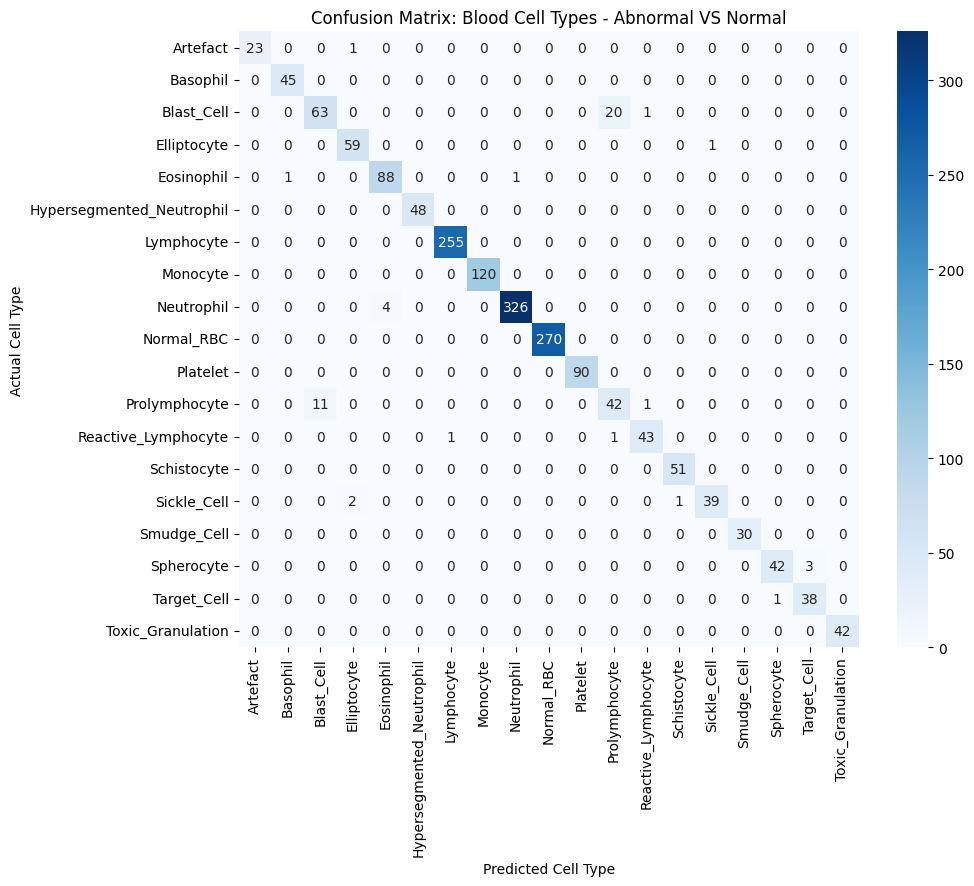

In [11]:
# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Cell Type')
plt.ylabel('Actual Cell Type')
plt.title('Confusion Matrix: Blood Cell Types - Abnormal VS Normal')
plt.show()

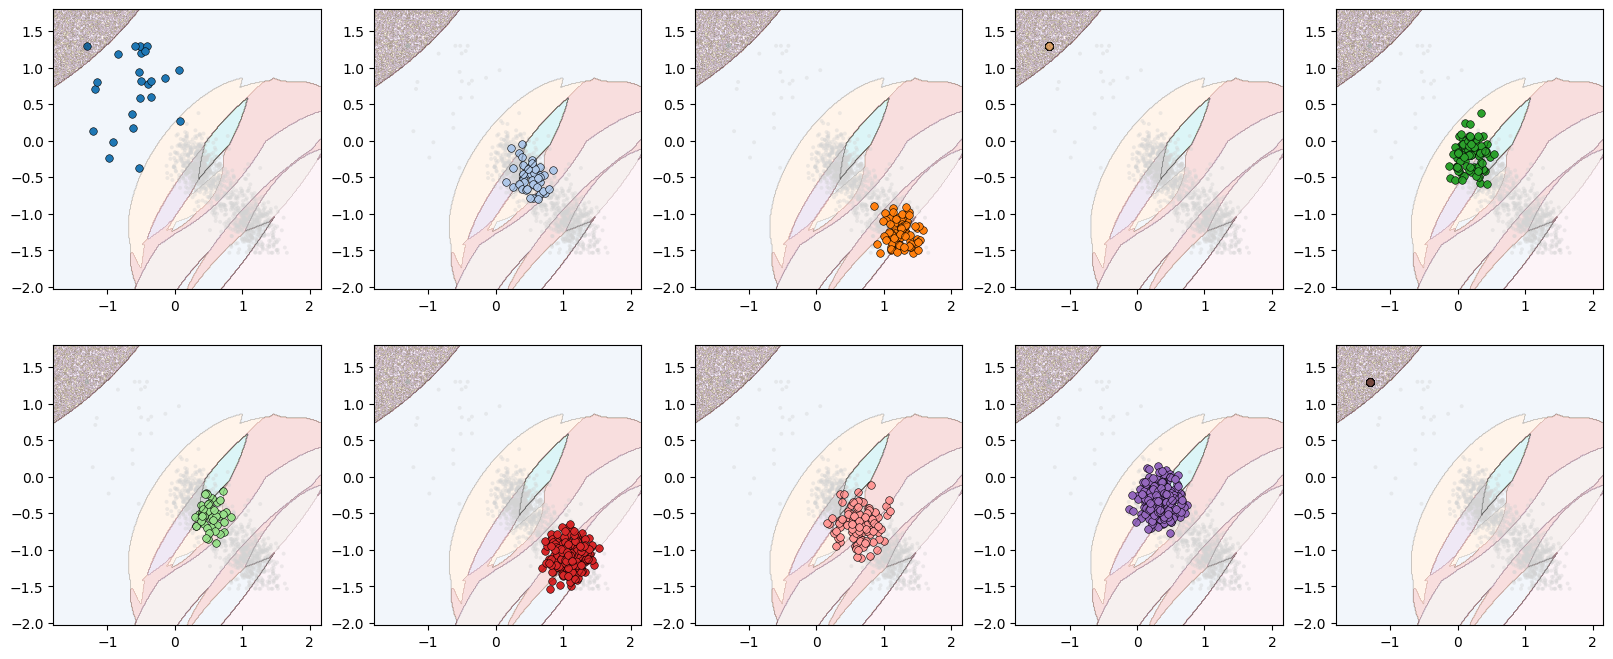

In [16]:
# RBF SVM decision boundary — 10 subplots, one per cell type
# Each plot highlights that class against the full decision regions

plot_features = ['nucleus_area_pct', 'cytoplasm_ratio']

scaler_2d = StandardScaler()
X_2d = scaler_2d.fit_transform(df[plot_features])
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y
)

svm_2d = SVC(kernel='rbf', gamma='scale', C=1.0, class_weight='balanced')
svm_2d.fit(X_train_2d, y_train_2d)

# Build mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
le = LabelEncoder().fit(svm_2d.classes_)
Z_enc = le.transform(Z).reshape(xx.shape)

classes    = svm_2d.classes_
n_classes  = len(classes)
colors     = plt.cm.tab20(np.linspace(0, 1, n_classes))
y_test_arr = np.array(y_test_2d)

# 2 rows x 5 cols — one subplot per class
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, cls in enumerate(classes[:10]):
    ax = axes[idx]

    # shared decision boundary background
    ax.contourf(xx, yy, Z_enc, alpha=0.15, cmap='tab20')
    ax.contour(xx, yy, Z_enc, colors='k', linewidths=0.2, alpha=0.3)

    # all other classes greyed out
    other_mask = y_test_arr != cls
    ax.scatter(X_test_2d[other_mask, 0], X_test_2d[other_mask, 1],
               color='lightgrey', s=8, alpha=0.4, edgecolors='none')

    # this class highlighted in its colour
    cls_idx = list(classes).index(cls)
    mask = y_test_arr == cls
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               color=colors[cls_idx], s=30, edgecolors='k', linewidths=0.4)

In [17]:
# Print some statistics
print(f"\nTotal test samples: {len(y_test)}")
print(f"Correctly classified: {(y_test == y_pred).sum()}")
print(f"Incorrectly classified: {(y_test != y_pred).sum()}")



Total test samples: 1764
Correctly classified: 1714
Incorrectly classified: 50


The dataset we chose was provides 5,880 blood cell records across 19 cell types, covering normal white blood cells, red blood cells, and platelets alongside 12 clinically significant abnormal cell types linked to leukemia, anemia, infections, and sickle cell disease. We developed a multiclass classification model using a Support Vector Machine (SVM) with a RBF kernel to classify different types of blood cells. We began by loading and exploring the dataset, which contains numerical features describing cell characteristics such as size, shape, and color intensity. After preprocessing the data and splitting it into training and testing sets, we trained the SVM model to learn complex, non-linear patterns between the features and the cell type labels. We then evaluated the model using accuracy and a confusion matrix to assess its performance across multiple classes, being the 19 cell types abnormal vs normal. The results demonstrate that the RBF kernel is effective in handling non-linear relationships in this multiclass dataset.

